# Seasonal Agriculture Performance Analysis

### Major Data Analytics Project

Domain: Agriculture

Project Theme: Seasonal Agriculture Performance

Tools: Python, Numpy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationship and differences in the available data.


Important: This is Data Analytics. No Machine Learning or dashboard development is required.

### 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data. 


### 2. Project Objective

 Explore and understand the dataset.

 Clean and prepare the data for analysis.

 Examine how agricultural performance varies across seasons.

 Identify important seasonal patterns and trends.

 Investigate relationships between seasonal conditions and agricultural outcomes.

 Compare relevant groups within different seasons.

 Identify significant differences or unusual patterns.

 Apply appropriate statistical and visualization techniques.

 Interpret findings based on evidence from the dataset.

 Develop meaningful conclusions and data-driven recommendations. 


### 3. Dataset
The dataset contains farm-level agriculture records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [35]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

In [36]:
#Load the dataset
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


### 4. Initial Data Understanding

In [37]:
#Dataset shape
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 4000
Number of columns: 28


In [38]:
# Top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [39]:
#Bottom 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [40]:
# Random sample of records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [41]:
#Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [42]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [43]:
# Numerical summary satistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [44]:
# Categorical summary
df.describe(include="object")

C:\Users\admin\AppData\Local\Temp\ipykernel_19212\354051415.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


### 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.
Student task: Explain what you observe and justify each cleaning decision

### Student Task: Observation and Cleaning Decisions

**Observation:** The dataset contained missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. The missing percentages were small. No duplicate records were found in the dataset. The data types of all variables were also examined.

**Cleaning Decision:** Since the missing values occurred in numerical variables and represented only a small percentage of the dataset, they were replaced using the median. Median imputation was selected because it is less affected by extreme values. Since no duplicate records were found, no duplicate rows needed to be removed. The data types were verified to ensure that the dataset was suitable for further analysis.

In [46]:
# Missing values
missing=df.isnull().sum().sort_values(ascending=False)
missing_percentage=(df.isnull().mean()*100).sort_values(ascending=False)
missing_summary=pd.DataFrame({
    "Missing_Count":missing,
    "Missing_Percentage":missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


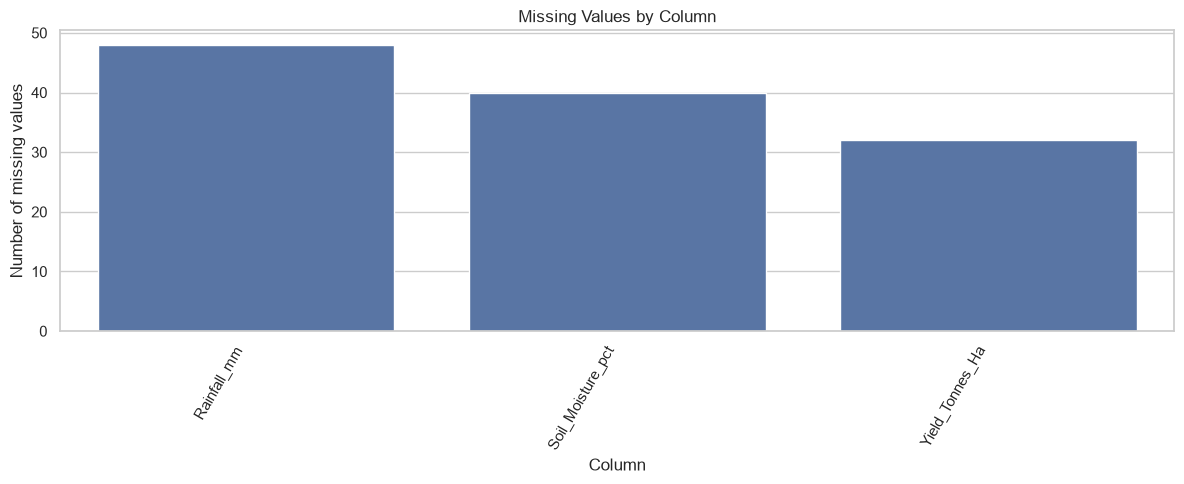

In [47]:
# Visualize missing values
plt.figure(figsize=(12,5))
missing_plot=missing[missing>0]
if len(missing_plot)>0:
    sns.barplot(x=missing_plot.index,y=missing_plot.values)
    plt.xticks(rotation=60,ha="right")
    plt.ylabel("Number of missing values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [48]:
# Duplicate records
duplicate_count=df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


In [49]:
# Remove duplicate rows
df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [50]:
# Check data types again
df.dtypes

Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [30]:
# Check unique values for catrgorical columns
categorical_columns=df.select_dtypes(include="object").columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(),"unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
<StringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014',
 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']
Length: 20, dtype: str

State:
8 unique values
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District:
10 unique values
<StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop:
8 unique values
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season:
3 unique values
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method:
4 unique values
<StringArray>
['Drip', 'Flood

C:\Users\admin\AppData\Local\Temp\ipykernel_13172\1560200684.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=df.select_dtypes(include="object").columns


In [51]:
# Check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64

## Missing Value Treatment
Choose an appropriate strategy based on the nature of each variable.

Possible approaches:

-> Remove records only when justified.

-> Fill numerical values using an appropriate statistics when appropriate.

-> Fill categorical values using a suitable category or method.

-> Clearly document why the chosen approach is reasonable.

Do not blindly replace every missing value with zero.

### Student Task: Relevant Variables

The most relevant variables for analyzing seasonal agricultural performance are Season, Crop, State, District, Rainfall_mm, Avg_Temperature_C, Humidity_pct, Soil_Moisture_pct, Yield_Tonnes_Ha, Production_Tonnes, and Profit_INR.

Season and Crop are important for comparing agricultural performance across different seasons and crops. Environmental variables such as rainfall, temperature, humidity, and soil moisture help examine how environmental conditions are associated with crop yield. Yield and Production directly represent agricultural performance, while Profit_INR helps evaluate the economic performance of farming. State and District can be used to compare geographical differences in agricultural performance.

In [52]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach.

numeric_columns=df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum()>0:
        df[col]=df[col].fillna(df[col].median())
print("Remaining missing values:",df.isnull().sum().sum())

Remaining missing values: 0


### 6. Feature / Variable Review
Review the available variables and classify them conceptually as:

-> Identifier variables

-> Categorical variables

-> Numerical variables

-> Environment variables

-> Operational variables

-> production/performance variables

-> Economic variables

In [53]:
# Numerical and categorical columns
numeric_columns= df.select_dtypes(include=np.number).columns.tolist()
categorical_columns= df.select_dtypes(include="object").columns.tolist()
print("Numerical columns:")
print(numeric_columns)
print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


C:\Users\admin\AppData\Local\Temp\ipykernel_19212\3227239742.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns= df.select_dtypes(include="object").columns.tolist()


### 7. Statistical Analysis
Perform descriptive statistical analysis to understand and variation of the data.

Students should interpret the statistics rather than simply displaying them.

In [54]:
# Descriptive statistics
stats=df[numeric_columns].describe().T
stats["range"]=stats["max"]-stats["min"]
stats["IQR"]=stats["75%"]-stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [55]:
# Median and standard deviation
statistical_summary=pd.DataFrame({
    "Mean":df[numeric_columns].mean(),
    "Median":df[numeric_columns].median(),
    "Std_Dev":df[numeric_columns].std(),
    "Min":df[numeric_columns].min(),
    "Max":df[numeric_columns].max()
})
statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [56]:
# Seasonal describe summary
season_summary=df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

Create and intrepret suitable plots for:

->Important categorical varibales.

->Important numerical variables

->Seasonal distribution

->Production/performance distribution

->Economic distribution

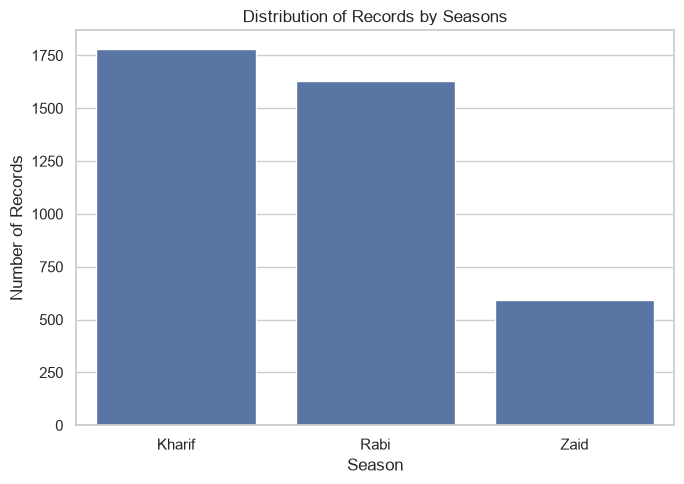

In [57]:
#Univariate: Season distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("Distribution of Records by Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

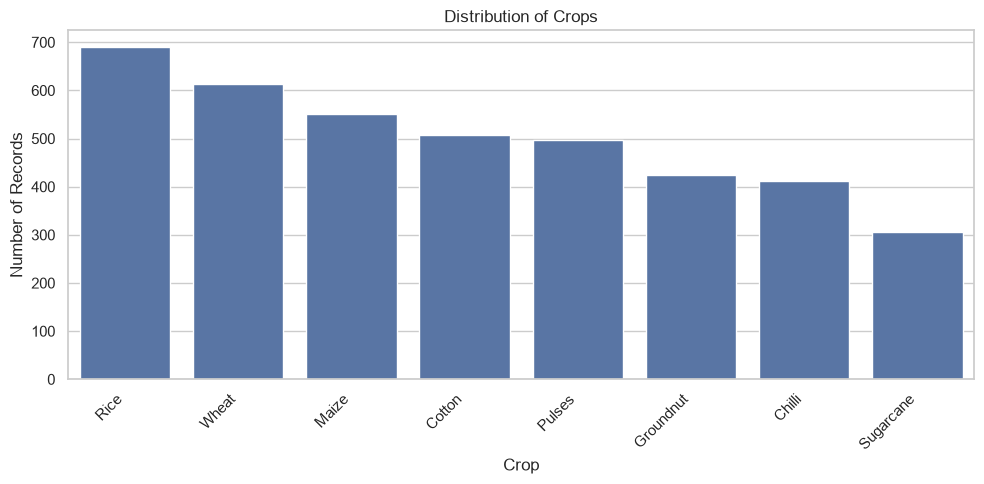

In [58]:
# Univariate Crop distribution

plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.xticks(rotation=45,ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

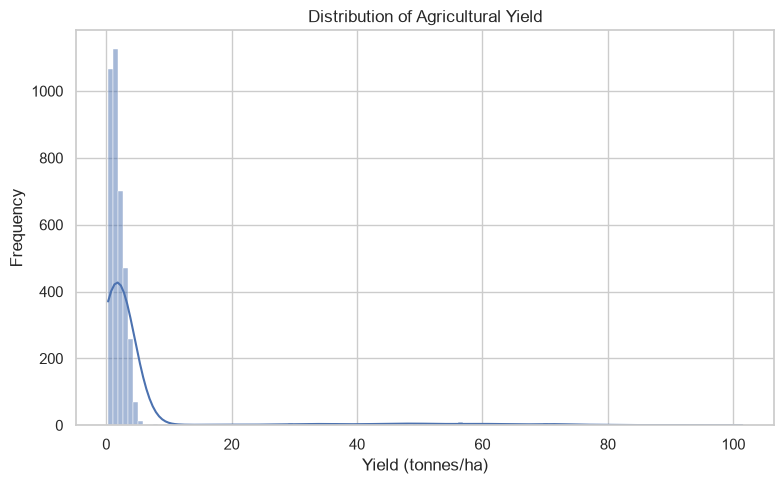

In [59]:
#Univarient: Yield distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

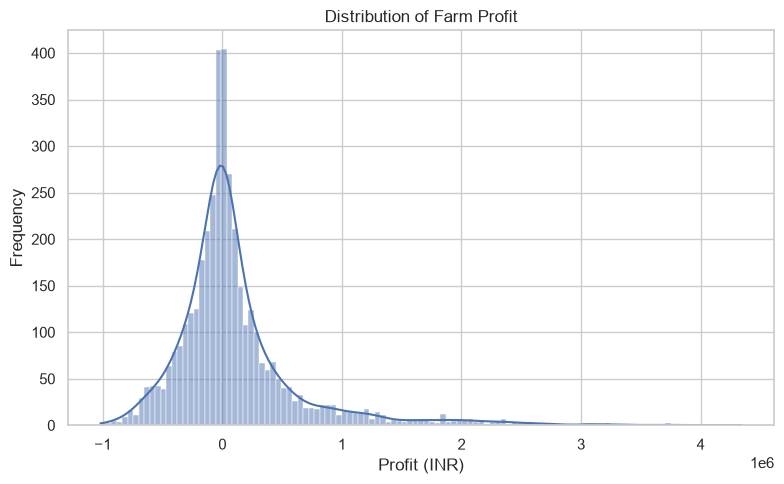

In [60]:
# Univariate: Profit distribution

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Profit_INR", kde=True)

plt.title("Distribution of Farm Profit")

plt.xlabel("Profit (INR)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

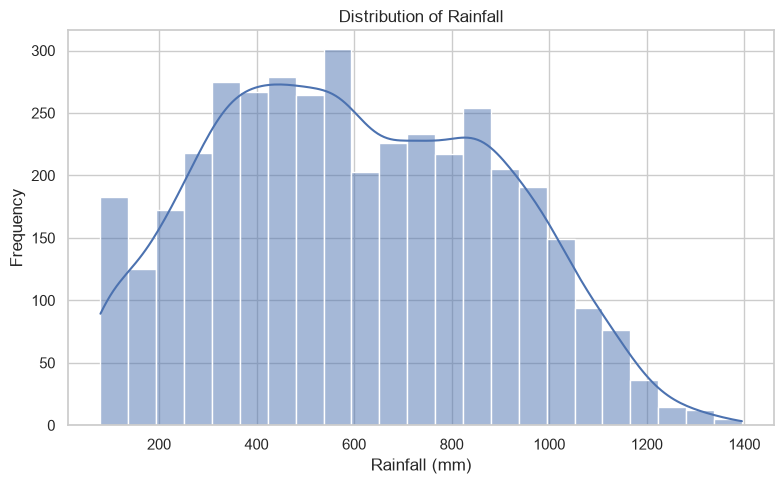

In [61]:
#Univarient: Yield distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

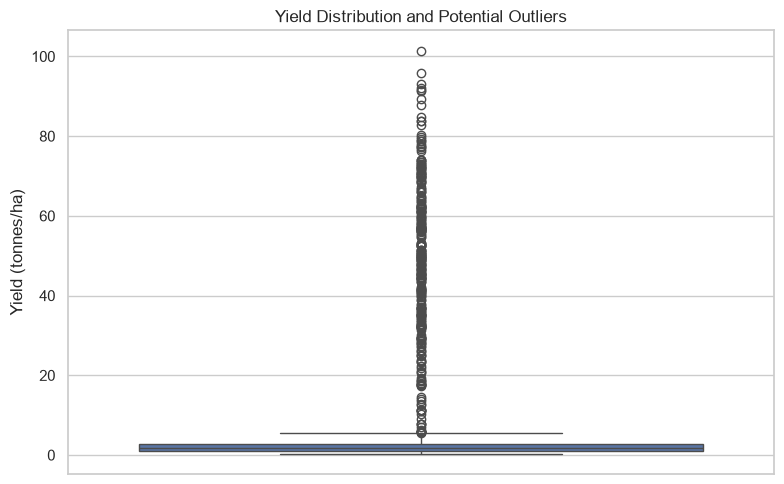

In [62]:
#Univarient: Boxplot for yield
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

### 9. Outlier Analysis
Investigate potential outliers using statistical and visual methods.

Student task: Do not automatically delete outliers. Decide whether an extreme value is:

->A data-entry problem,

->A legitimate observation,

->Or something requiring future investigtaion.

### Univariate: Season distribution (Pie Chart)

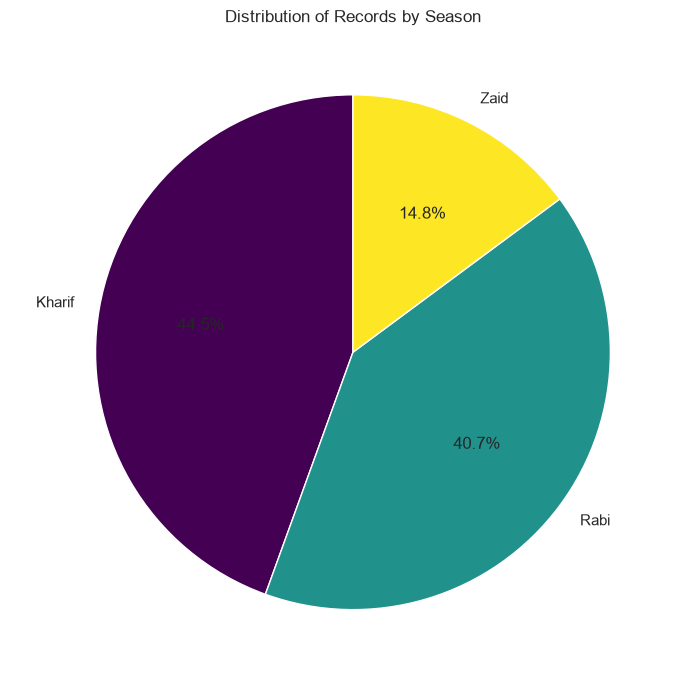

In [63]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.title("Distribution of Records by Season")
plt.ylabel(" ")
plt.tight_layout()
plt.show()

In [64]:
#IQR-based outlier summary for numerical columns
outlier_summary=[]
for col in numeric_columns:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    count=((df[col]<lower) | (df[col]>upper)).sum()
    outlier_summary.append({
        "Column":col,
        "Lower_Round":lower,
        "Upper_Bound":upper,
        "Outlier_Count":count,
        "Outlier_Percentage": round(count/len(df)*100,2)
    })
outlier_summary=pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count",ascending=False
)
outlier_summary

,Column,Lower_Round,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


### Outlier Analysis Interpretation

The IQR method identified potential outliers in variables such as Profit_INR, Production_Tonnes, Yield_Tonnes_Ha, Water_Used_m3, and Revenue_INR. These outliers were not automatically removed because extreme agricultural and economic values may represent genuine differences between farms, crops, or farming conditions. Since there was no clear evidence that these values were data-entry errors, they were retained for further analysis.

### Bivariate Analysis

Bivariate analysis examines relationships or difference between two variables.

Student should investigate relationship that are relevant to the seasonal agriculture problem.

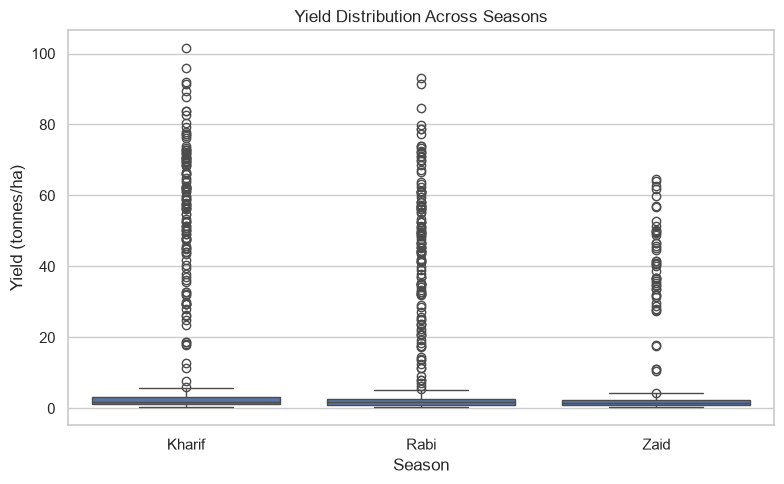

In [65]:
# Bivariate: Season vs Yield
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

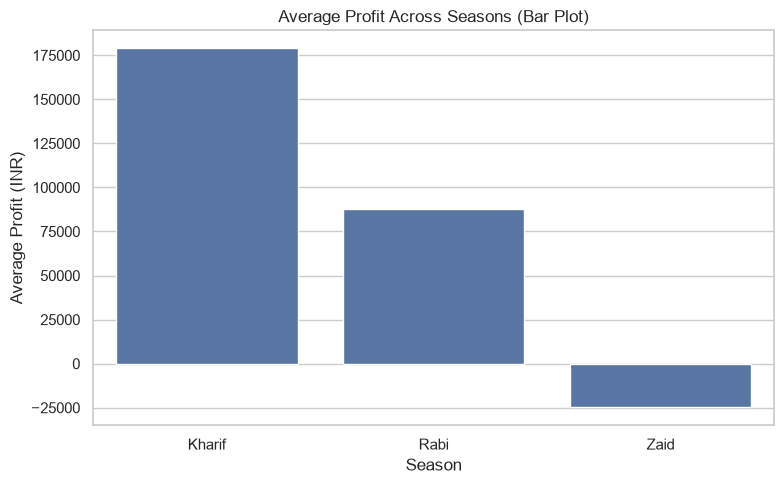

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

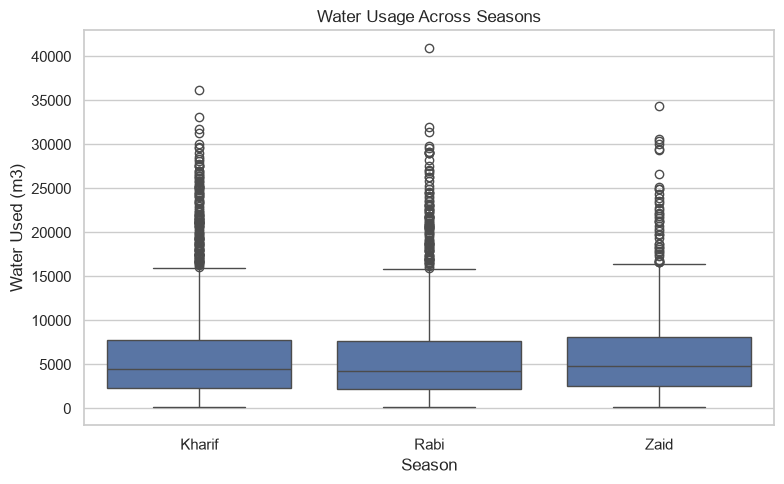

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()

### Bar plots for Bivariate Analysis

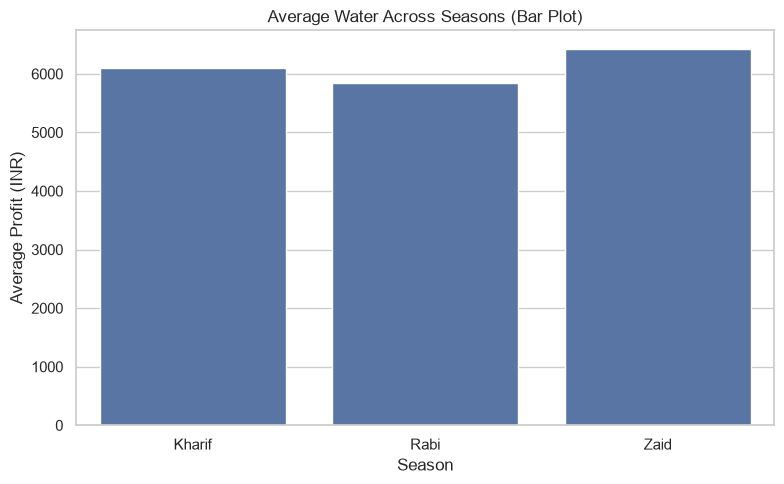

In [68]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Average Water Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

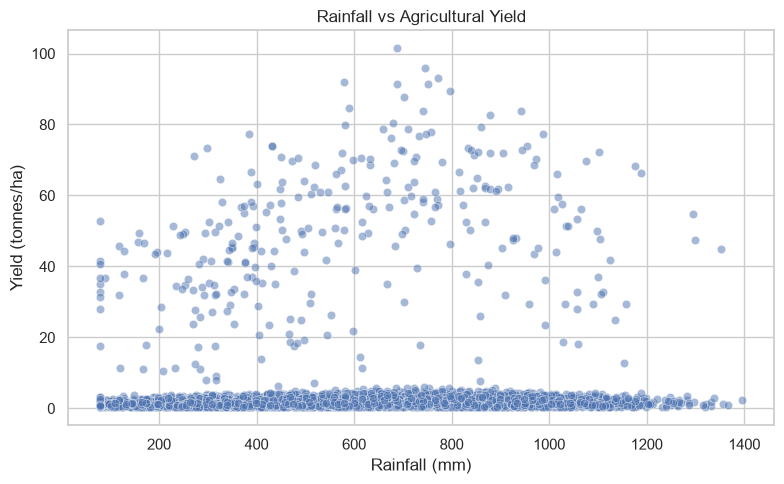

In [69]:
# Bivariate: Rainfall vs Yield
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

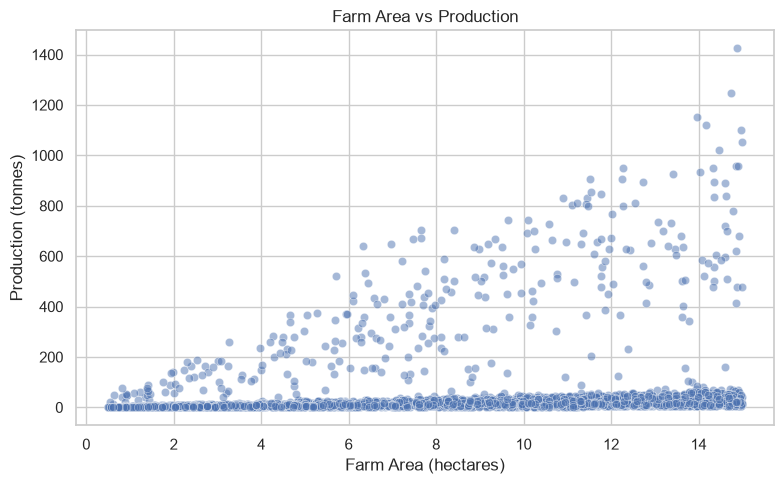

In [70]:
# Bivariate: Farm area vs Production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_19212\1042378502.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


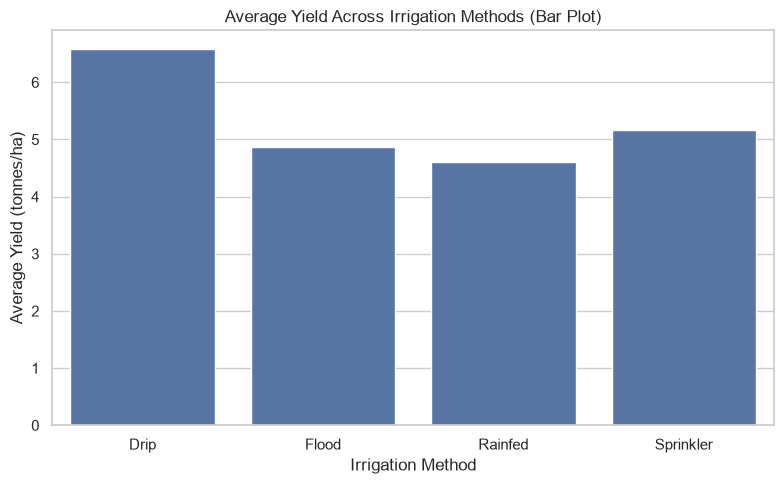

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    ci=None
)

plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

### 11. Multivarient Analysis

Multivarient Analysis examines more than two variables together.

Use multivarient plots to investigate how season interact with such as crop, region, environmental conditions, resource usage or economic performance

C:\Users\admin\AppData\Local\Temp\ipykernel_19212\1962095919.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


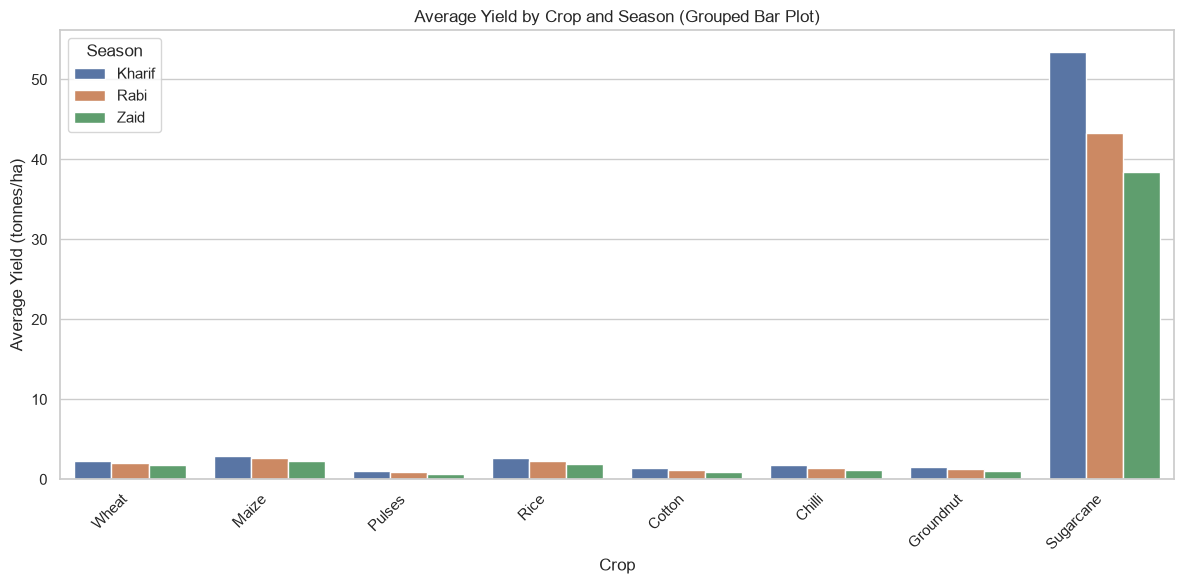

In [72]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season",
    order=["Wheat", "Maize", "Pulses", "Rice", "Cotton", "Chilli", "Groundnut", "Sugarcane"],
    hue_order=["Kharif", "Rabi", "Zaid"],
    ci=None
)

plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.legend(title="Season")

plt.tight_layout()
plt.show()

### Multivarient: Pair Plot of Key Environmental and Performance Metrices by Season

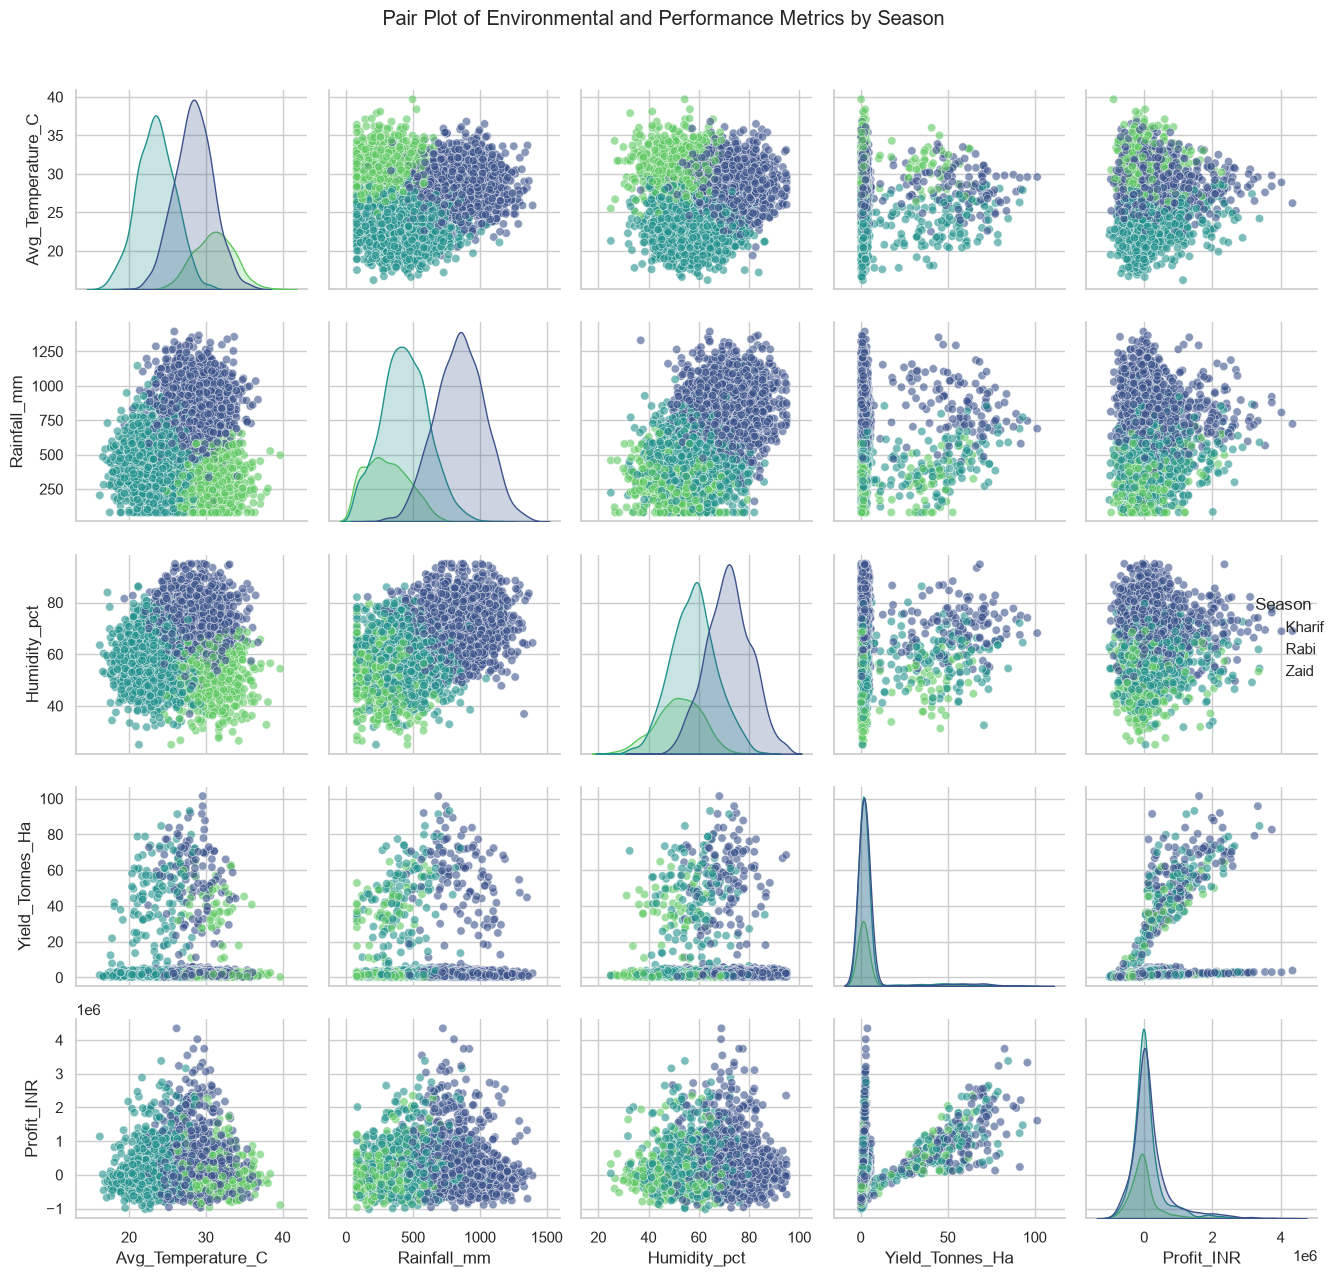

In [73]:
selected_columns=['Avg_Temperature_C', 'Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns],hue='Season',palette='viridis',plot_kws={'alpha':0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season',y=1.02)
plt.tight_layout()
plt.show()

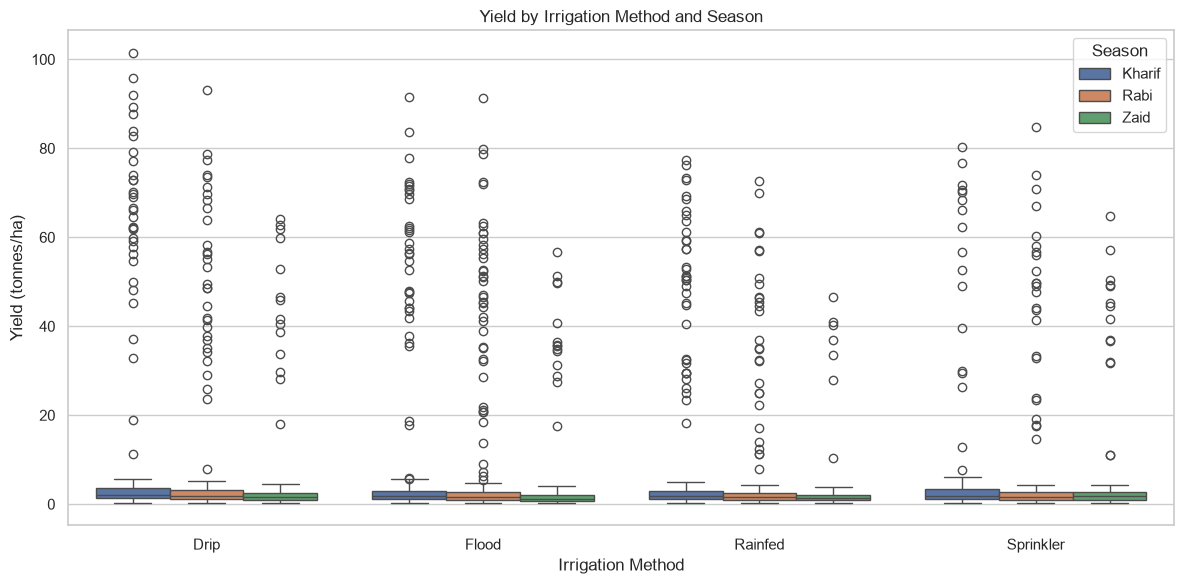

In [74]:
#Multivarient: Season, irrigation and yield
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

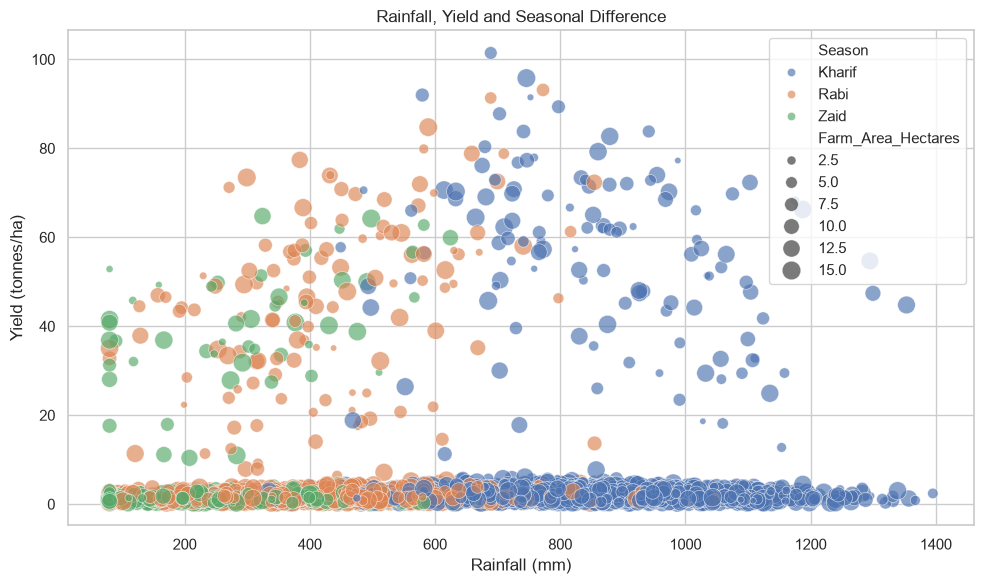

In [75]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)

plt.title("Rainfall, Yield and Seasonal Difference")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

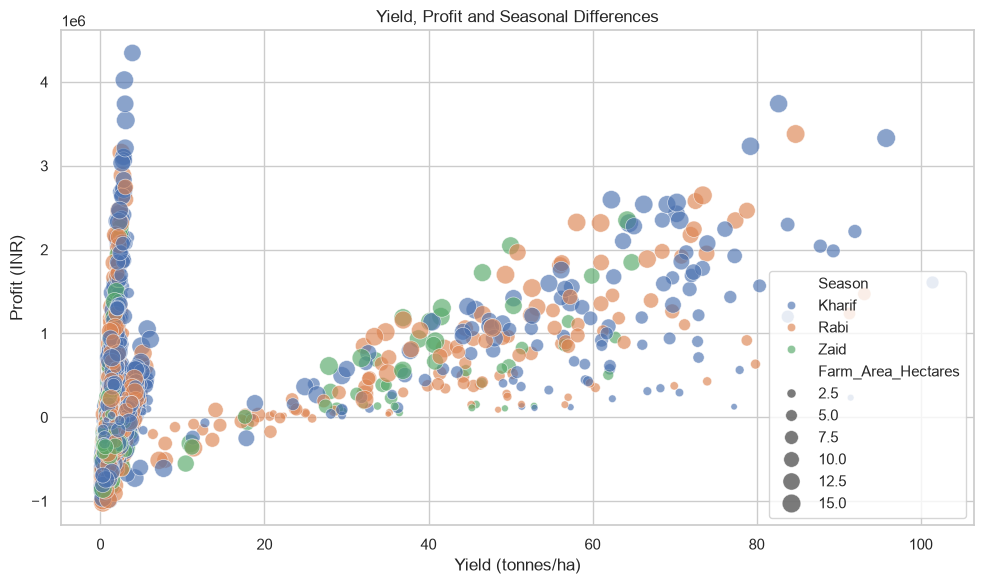

In [76]:
#Multivariate: Profit, yield and season
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

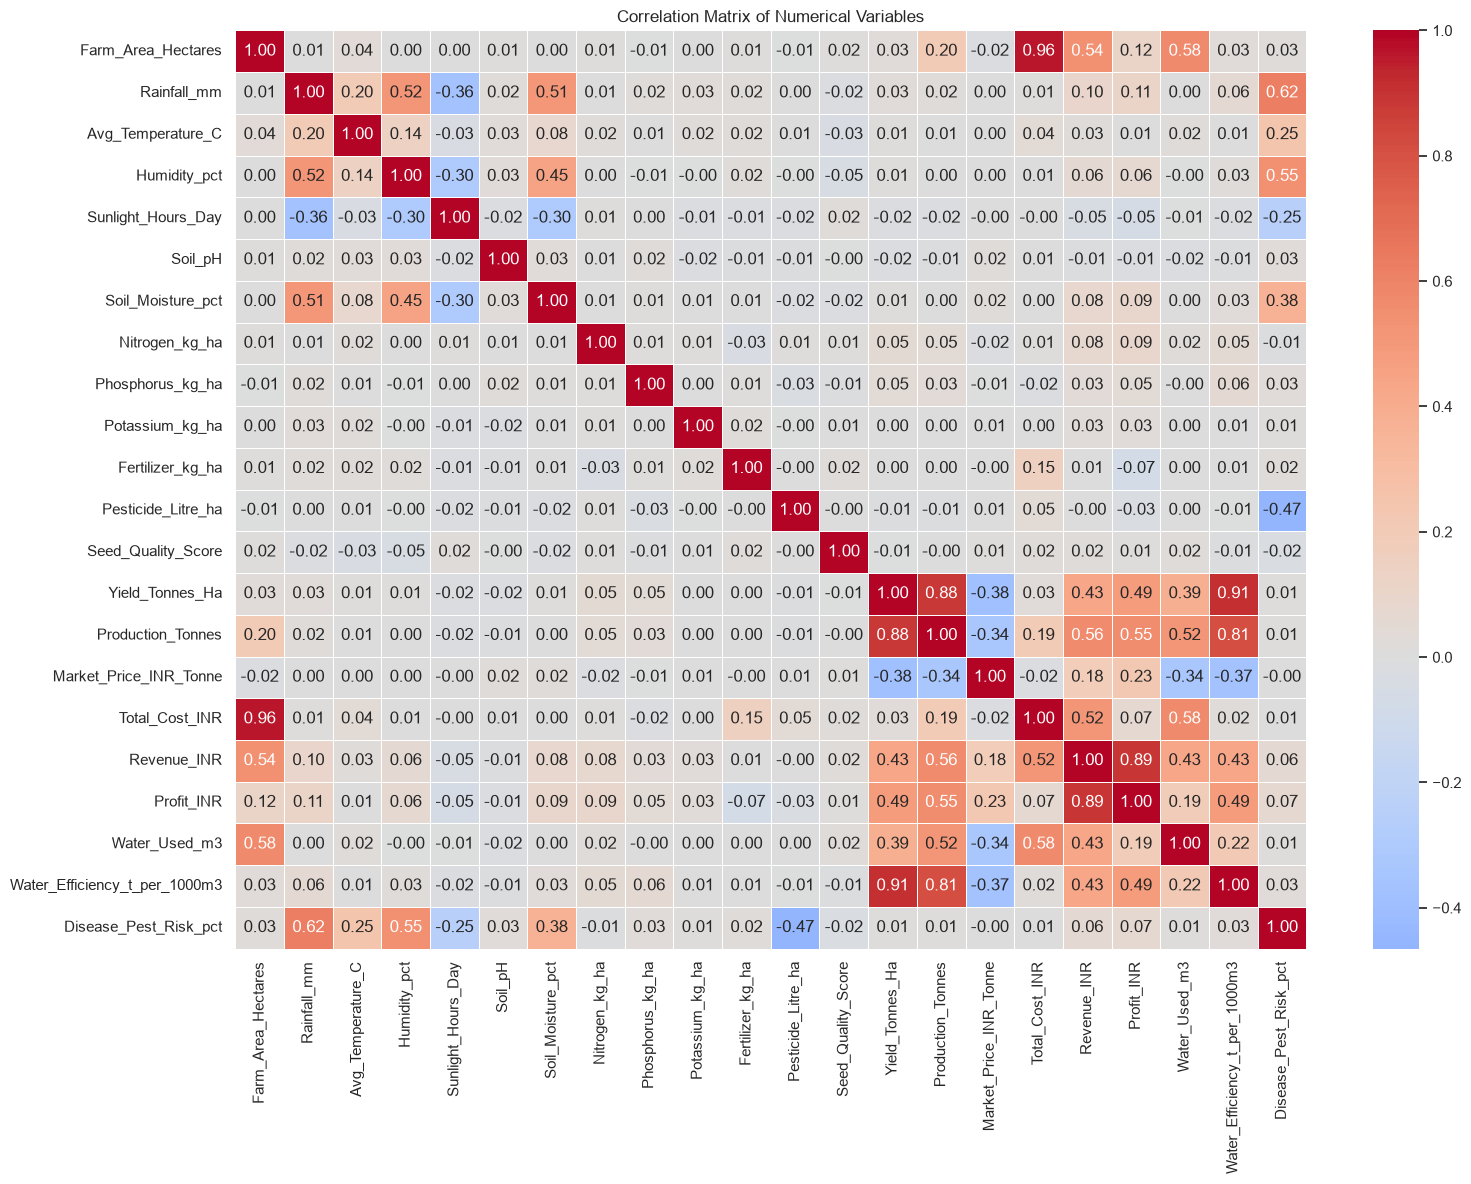

In [77]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(16,12))
corr=df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidth=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 12. Seasonal Comparison
Students should now move from indivual plots to structured comparions.

### Student task
Create suitable summary tables and visualizationa to compare seasons across meaningful measures.

Do not assume that every variable needs to be compared. Select variables that help answer the project problem.


In [47]:
#General seasonal_summary
season_metrics=df.groupby("Season").agg(
    Records=("Farm_ID","count"),
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Total_Production=("Production_Tonnes","sum"),
    Average_Profit=("Profit_INR","mean"),
    Total_Profit=("Profit_INR","sum"),
    Average_Water_Used=("Water_Used_m3","mean")
).round(2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


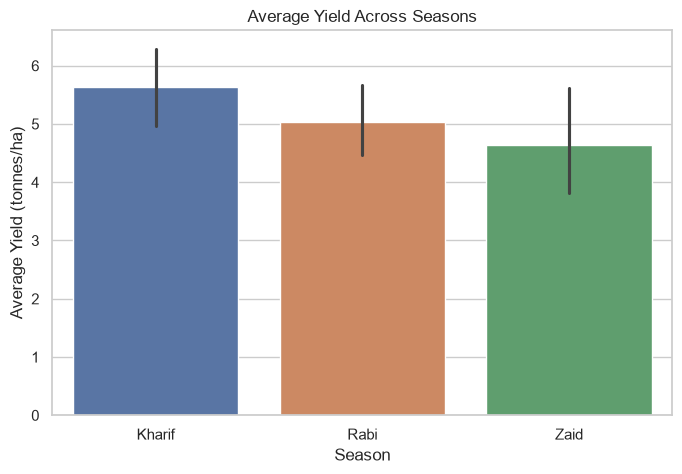

In [78]:
#Visualization – Compare average yield by season
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    hue="Season",
    legend=False
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.show()

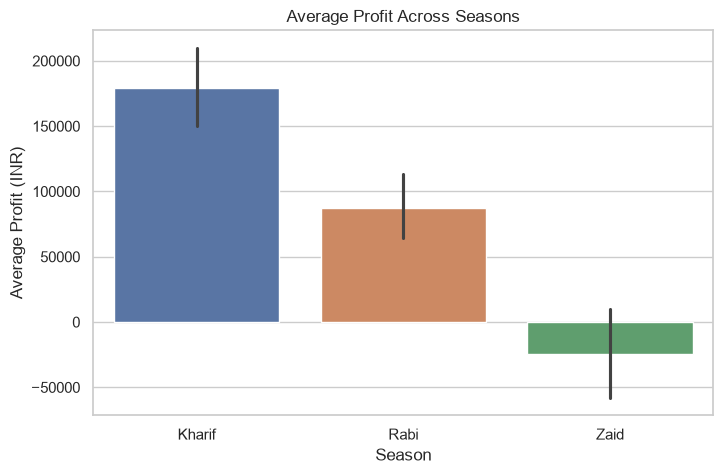

In [79]:
#Visualization – Compare average profit by season
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    hue="Season",
    legend=False
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

In [48]:
# Compare crop performance within each season
crop_season_summary=(
    df.groupby(["Season","Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha","mean"),
        Average_Profit=("Profit_INR","mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
    )
    .round(2)
    .sort_values(["Season","Average_Yield"],ascending=[True,False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

### 13. Additional Student-Driven Analysis

This section is intentionally open-ended.

Students should add at least 3 additional analyses that are not already provided above.

Possible direction include:

-> Regional difference

-> Crop-specific seasonal patterns

-> Resource usage

-> Economic performance

-> Environmental conditions

-> Risk Patterns

-> Relationships discovered during exploration

The student must explain why each additional analysis is relevant to the project problem.

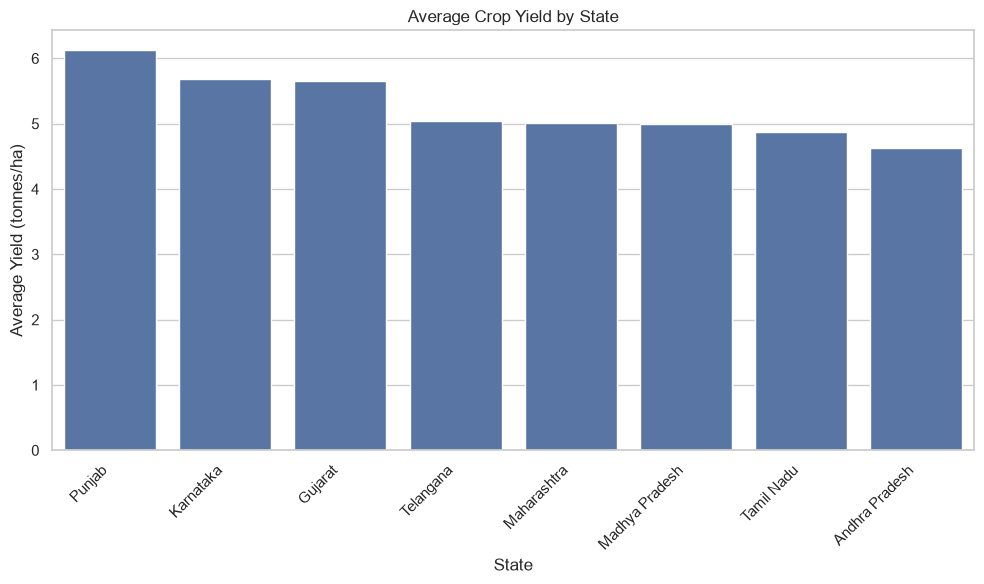

In [54]:
# Student Analysis 1
# Question: Which states have the highest average crop yield?

# Analysis:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

# Visualization:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=state_yield.index,
    y=state_yield.values
)

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

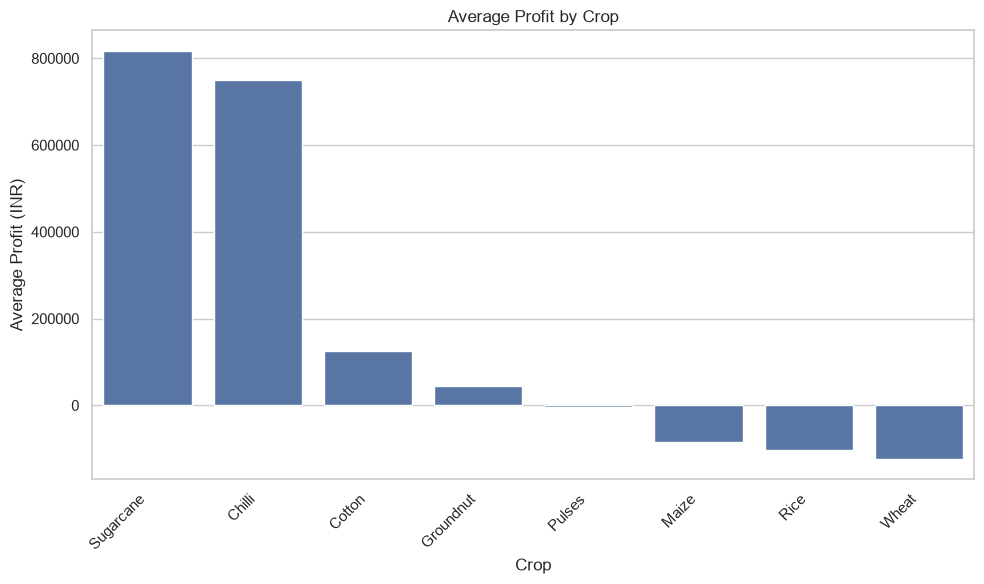

In [55]:
# Student Analysis 2
# Question: Which crops generate the highest average profit?

# Analysis:
crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

# Visualization:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.index,
    y=crop_profit.values
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Interpretation:
# This analysis helps identify which crops are more profitable.

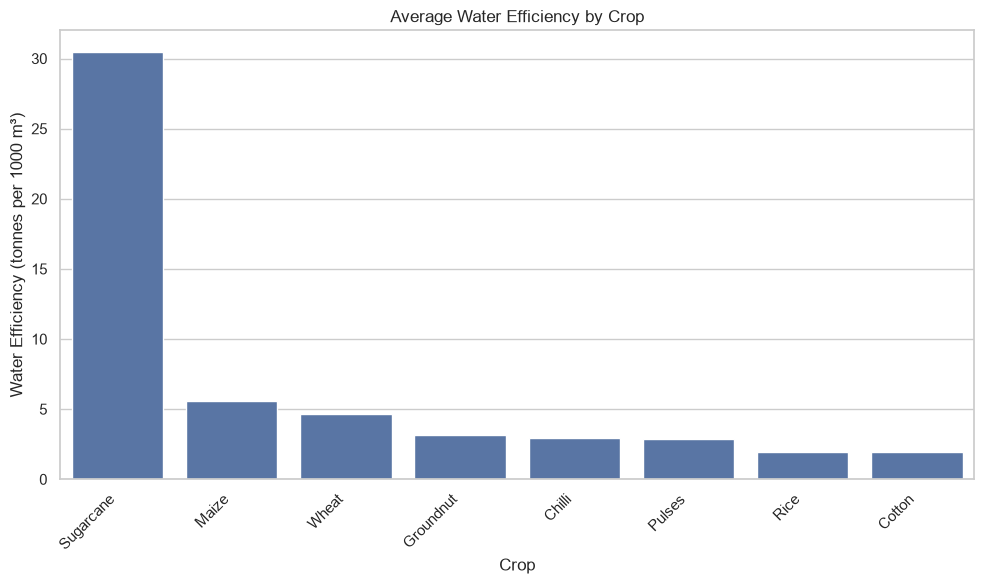

In [80]:
# Student Analysis 3
# Question: Which crops have the highest water efficiency?

crop_water_efficiency = (
    df.groupby("Crop")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_water_efficiency.index,
    y=crop_water_efficiency.values
)

plt.title("Average Water Efficiency by Crop")
plt.xlabel("Crop")
plt.ylabel("Water Efficiency (tonnes per 1000 m³)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 14. Key Insights

Write at least 8 meaningful insights from the analysis.

For each insight, follow this structure:

1. Observation - What did you observe?

2. Evidence Which analysis supports it?

3. Interpretation - What does the evidence indicate?

4. Limitation - What should not be assumed from the finding?

Avoid statements that claim causation when the analysis only shows association.

# Key Insights

### 1. Observation
Kharif had the highest average yield among the three seasons.

**Evidence:** The seasonal comparison showed an average yield of 5.63 tonnes/ha for Kharif, compared with 5.04 tonnes/ha for Rabi and 4.64 tonnes/ha for Zaid.

**Interpretation:** Agricultural productivity was higher in the Kharif season in this dataset.

**Limitation:** This does not prove that the season alone caused the higher yield.

---

### 2. Observation
Kharif had the highest total production.

**Evidence:** Total production was 82,387.61 tonnes in Kharif, compared with 67,498.88 tonnes in Rabi and 23,098.35 tonnes in Zaid.

**Interpretation:** Kharif contributed the largest share of agricultural production in the dataset.

**Limitation:** Total production may also be influenced by the number of farms and farm sizes.

---

### 3. Observation
Zaid had a negative average profit.

**Evidence:** The average profit for Zaid was -24,804.82 INR, while Kharif and Rabi had positive average profits of 178,914.65 INR and 87,689.47 INR respectively.

**Interpretation:** Economic performance was weaker during the Zaid season in this dataset.

**Limitation:** Profit can also be affected by production costs and market prices.

---

### 4. Observation
Water usage varied across seasons.

**Evidence:** Average water used was 6,102.20 m³ in Kharif, 5,846.99 m³ in Rabi, and 6,419.89 m³ in Zaid.

**Interpretation:** Zaid had the highest average water usage despite having the lowest average yield.

**Limitation:** Water usage alone does not explain overall agricultural performance.

---

### 5. Observation
Sugarcane had much higher average yields than the other crops.

**Evidence:** In the crop-season analysis, Sugarcane had average yields of 53.46 tonnes/ha in Kharif, 43.29 tonnes/ha in Rabi, and 38.42 tonnes/ha in Zaid.

**Interpretation:** Sugarcane was the highest-yielding crop in the dataset across all three seasons.

**Limitation:** Yield comparisons should consider differences in crop characteristics and farming requirements.

---

### 6. Observation
Crop profitability varied significantly across crops and seasons.

**Evidence:** Sugarcane and Chilli showed high average profits, while some crops such as Wheat, Rice, and Maize showed negative average profits in several seasons.

**Interpretation:** Higher crop production does not always guarantee higher economic returns.

**Limitation:** Profitability may change depending on market prices and production costs.

---

### 7. Observation
The dataset contained substantial variation in yield and profit.

**Evidence:** Yield ranged from 0.30 to 101.44 tonnes/ha, while Profit_INR ranged from approximately -1,019,223 INR to 4,345,421 INR.

**Interpretation:** Agricultural and economic performance differs considerably between farms and observations.

**Limitation:** Some extreme values may represent unusual but legitimate observations.

---

### 8. Observation
Agricultural performance is associated with multiple factors.

**Evidence:** The bivariate and multivariate analyses examined relationships involving season, crop, rainfall, irrigation, yield, production, and profit.

**Interpretation:** Agricultural performance cannot be explained by a single factor.

**Limitation:** The observed relationships show association and do not establish direct causation.

# 15. Recommendations

1. **Give importance to Kharif seasonal planning:** Since Kharif showed the highest average yield and total production, successful practices used during this season can be further studied and applied where appropriate.

2. **Investigate Zaid economic performance:** Zaid had a negative average profit and should be further examined for factors such as production cost, market price, crop selection, and resource usage.

3. **Improve water efficiency:** Zaid had the highest average water usage but the lowest average yield. Water management practices should therefore be evaluated to improve efficiency.

4. **Consider crop-specific planning:** Sugarcane showed consistently high average yields across seasons, while other crops showed lower yields and profitability. Crop selection should consider both productivity and economic performance.

5. **Evaluate profit along with production:** High production does not automatically guarantee high profit. Farmers should consider costs, market prices, revenue, and profit together.

6. **Study successful farming conditions:** High-performing states and crops can be further investigated to identify environmental or farming practices associated with better outcomes.

7. **Use multiple factors for decision-making:** Agricultural planning should consider season, crop, rainfall, irrigation, yield, production, and profit together.

**Limitation:** These recommendations are based on patterns observed in the dataset and do not establish direct cause-and-effect relationships.

# 16. Conclusion

This project analyzed seasonal agricultural performance using environmental, production, resource usage, and economic variables. The analysis showed meaningful differences between Kharif, Rabi, and Zaid seasons.

Kharif showed the highest average yield, total production, and average profit. Rabi showed moderate performance, while Zaid had the lowest average yield and a negative average profit despite having the highest average water usage.

The crop-level analysis showed that Sugarcane had considerably higher yields across all seasons, while profitability varied between crops. Overall, the findings indicate that agricultural performance is associated with multiple environmental, operational, geographical, and economic factors.

The analysis can support better seasonal agricultural planning and data-driven decision-making. However, the observed patterns represent associations and further investigation would be required to establish direct causal relationships.

# 17. Project Checklist
Before submission, confirm that your notebook includes:

Dataset loaded successfully

Top 5 rows analyzed

Dataset shape and structure examined

Data types examined

Missing values identified and handled

Duplicate records identified and handled

Descriptive/statistical analysis performed

Outliers investigated

Univariate analysis completed

Bivariate analysis completed

Multivariate analysis completed

Correlation analysis completed

Seasonal comparisons performed

At least 3 student-designed analyses completed

At least 8 meaningful insights documented

Evidence-based recommendations provided

Limitations discussed

Final conclusion provided